# Transparent Surface Segmentation - LabRoM

This project aims to test and evaluate different semantic segmentation models, such as YOLO, on segmenting transparent surfaces, such as glass objects, windows, doors, etc. The purpose of this project is related to real-time computer vision systems like robots, whose main sensor is laser-based (such as LiDAR). One major problem with this kind of sensor is that light passes through such surfaces, so the robot thinks there is no obstacle in that region, which can lead to crashes and significant damage to the system. Detecting these surfaces is a powerful ally to LiDAR-based navigation, offering a computational solution to this type of physical limitation.

In order to accomplish this evaluation, a big and good dataset is needed. So, it was decided that the chosen dataset for this project is [Trans10K](https://paperswithcode.com/dataset/trans10k), by **Xie *et al***. This dataset is described as "a large-scale dataset for transparent object segmentation, consisting of 10,428 images of real scenarios with carefully manual annotations, which are 10 times larger than the existing datasets", in the author's own words.

## References

- **Segmenting Transparent Objects in the Wild**, by Xie *et al.*
    - [Github](https://github.com/xieenze/Segment_Transparent_Objects)
    - [Paper](https://arxiv.org/pdf/2003.13948)
    



## Getting YOLO annotations

Trans10K annotations consists on masks, which is a binary image. For each original image, in RGB, there is a mask that is only black and white, where the white part of it is what we want to segment. For instance, check these images below. 

<table align="center">
  <tr>
    <td align="center">
      <img src="photos/4.jpg" alt="Original image" height="275"><br>
        Original image
      </a>
    </td>
    <td align="center">
      <img src="photos/4_mask.png" alt="Mask" height="275"><br>
        Mask
      </a>
    </td>
  </tr>
</table>

YOLO requires a different kind of annotation. Instead of masks, YOLO demands a **.txt** file with all the points of the **Polygon** that comprehends the object. The required format is like:

```txt
<class_id> <x1> <y1> <x2> <y2> ... <xn> <yn>
```

Where **class_id** is the ID of the object that this polygon is delimiting. In our case, it will always be 0, because glass is the only object (or surface) that we are interested in.

Since the annotations are in the wrong format, we must convert them to YOLO format. Instead of manually annotating 10,428 images, we can code an algorithm to do it for us.


In [22]:
import os

mask_folder = "masks"
images_folder = "images"
labels_folder = "labels"
dataset_folder = "dataset"

# Creating all required folders
os.makedirs(mask_folder, exist_ok=True)     # All masks must be here
os.makedirs(images_folder, exist_ok=True)   # All original images must be here
os.makedirs(labels_folder, exist_ok=True)   # All labels will be written here
os.makedirs(dataset_folder, exist_ok=True)  # The final YOLO dataset will be located here

The dataset must be downloaded and extracted to these folders before the next steps.

To make this notebook more compact, some useful functions are defined in `helper_functions.py`. You can check the algorithm to, given a mask image, generate a YOLO annotation label. 

We could just call `generate_yolo_annotation()` on every image and it would work perfectly. But doing this, Python would process all the masks **sequentially**, which isn't that efficient. This task can clearly be **parallelized** using threads, in order to take less time. So let's divide the task into different threads. 

In [23]:
from helper_functions import generate_yolo_annotation
import threading

# Defining parameters for parallelizing 
N_THREADS = os.cpu_count()
threads = []

# The files will be equally divided through threads
file_list = [os.path.join(mask_folder, f) for f in os.listdir(mask_folder) if f.endswith((".png"))]
cut_size = int(len(file_list)/N_THREADS)

# Calls the function for each cut of the file list
for i in range(N_THREADS):

    start = i*cut_size
    end = (i + 1) * cut_size if i < N_THREADS - 1 else len(file_list)

    file_list_cut = file_list[start:end]

    thread = threading.Thread(target=generate_yolo_annotation, args=(file_list_cut, labels_folder))
    threads.append(thread)
    thread.start()

# Wait for all threads to finish
for i in range(N_THREADS):
    threads[i].join()

No contour found for mask masks/470_mask.png.


Let's test if our label generator really worked. We are going to plot the polygon over the original image, for N times, in order to visually inspect the label.

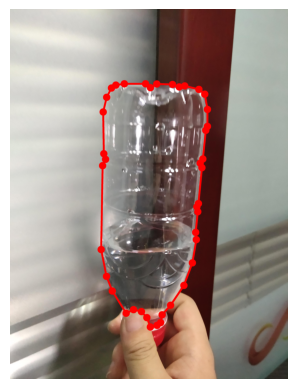

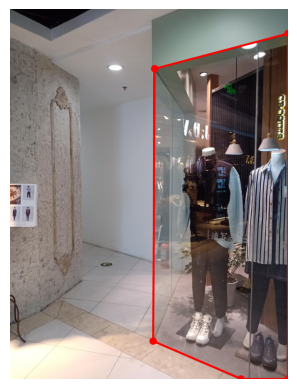

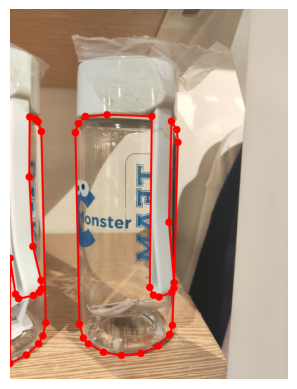

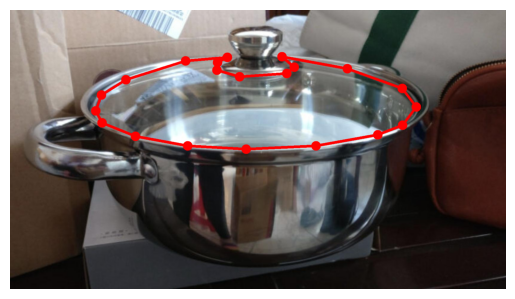

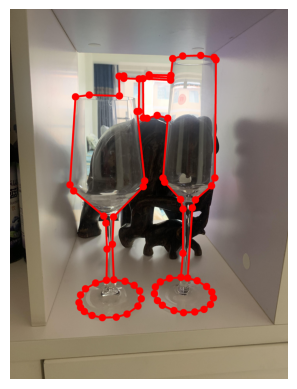

In [ ]:
from helper_functions import polygon_visual_inspection

images_folder = "images"
labels_folder = "labels"
# images_folder = "dataset/images/train"
# labels_folder = "dataset/labels/train"

polygon_visual_inspection(images_folder, labels_folder, 5)

It worked! You can see that the polygon fits correctly to the objects we wanted to segment. So basically, the annotation process is finished! Let's put the dataset in the correct format now. 

## Creating the Dataset

Now that our images are all labelled and annotated, it's time to split them into train, validation and test datasets. YOLO requires the following directory structure:

```txt
dataset/
│── images/
│   ├── train/   
│   ├── val/     
│   ├── test/    
│── labels/
│   ├── train/   
│   ├── val/     
│   ├── test/    
│── data.yaml    # Dataset configuration file (informations about the dataset)
```

In [25]:
import os
import random

SEED = 42

# Creating the images and labels folders
os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/labels/train", exist_ok=True)
os.makedirs("dataset/images/test", exist_ok=True)
os.makedirs("dataset/labels/test", exist_ok=True)
os.makedirs("dataset/images/val", exist_ok=True)
os.makedirs("dataset/labels/val", exist_ok=True)

# Splits of the dataset
train_split = 0.8
val_split = 0.1

# Shuffling the dataset
images_list = os.listdir(images_folder)
random.seed(SEED)
random.shuffle(images_list)

# Calculating the splits
train_set_size = int(len(images_list) * train_split)            # 80%
remaining = len(images_list) - train_set_size
val_set_size = int(remaining * val_split / (1 - train_split))   # 10%
test_set_size = remaining - val_set_size                        # 10%

# Splitting the data
train_set = images_list[ : train_set_size]
val_set = images_list[train_set_size : train_set_size + val_set_size]
test_set = images_list[train_set_size + val_set_size : ]

# Verify sizes
print(len(train_set), len(val_set), len(test_set))

8343 1043 1043


Now they are proportionally and randomly divided. Let's save them into the correct folders with Try-Catch.

In [28]:
for img in train_set:
    try:
        os.replace(os.path.join(images_folder, img), os.path.join(dataset_folder, "images/train", img))
        label = img.replace(".jpg", ".txt")
        os.replace(os.path.join(labels_folder, label), os.path.join(dataset_folder, "labels/train/", label))
    except(Exception):
        continue

for img in val_set:
    try: 
        os.replace(os.path.join(images_folder, img), os.path.join(dataset_folder, "images/val", img))
        label = img.replace(".jpg", ".txt")
        os.replace(os.path.join(labels_folder, label), os.path.join(dataset_folder, "labels/val/", label))
    except(Exception):
        continue

for img in test_set:
    try: 
        os.replace(os.path.join(images_folder, img), os.path.join(dataset_folder, "images/test", img))
        label = img.replace(".jpg", ".txt")
        os.replace(os.path.join(labels_folder, label), os.path.join(dataset_folder, "labels/test/", label))
    except(Exception):
        continue

Now, our job is to create the `data.yaml` file. It contains informations about the dataset, and YOLO requires it. The text file in this case must be the following:

```txt
train: dataset/images/train  
val: dataset/images/val      
test: dataset/images/test    

nc: 0
names: ["glass"]  
```



In [ ]:
import yaml

data = {
    'train': os.path.join(os.getcwd(), 'dataset/images/train'),
    'test': os.path.join(os.getcwd(), 'dataset/images/test'),
    'val': os.path.join(os.getcwd(), 'dataset/images/val'),
    'nc': 1, 
    'names': ['glass']
}

data_yaml_path = 'dataset/data.yaml'

with open(data_yaml_path, 'w') as file:
    yaml.dump(data, file)

print(f"File {data_yaml_path} generated succesfully!")


File dataset/data.yaml generated succesfully!


Finally, it's everything ready to start training YOLO models.

## Training YOLO

Training an AI model requires setting some hyperparameters. These are values that the programmer set by itself, based on the problem and on previous knowledge.

- BATCH_SIZE
- EPOCHS


In [ ]:
from ultralytics import YOLO
import torch

# Hyperparameters
EPOCHS = 50
BATCH_SIZE = 8
IMG_SIZE = 640
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Downloading our model
model = YOLO("yolov8n-seg.pt")

# Using GPU if it is available
model.to(device)
print(f"Training device on {device}.")

# Training model on dataset
model.train(data="dataset/data.yaml", epochs=EPOCHS, batch=BATCH_SIZE, imgsz=IMG_SIZE)

Training device on cpu.
New https://pypi.org/project/ultralytics/8.3.94 available 😃 Update with 'pip install -U ultralytics'
engine/trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=dataset/data.yaml, epochs=50, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cpu, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_l

train: Scanning /Users/marco/iC/yolo-labrom/dataset/labels/train.cache... 8342 images, 1 backgrounds, 0 corrupt: 100%|██████████| 8343/8343 [00:00<?, ?it/s]
val: Scanning /Users/marco/iC/yolo-labrom/dataset/labels/val.cache... 1042 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1042/1042 [00:00<?, ?it/s]

Plotting labels to /Users/marco/iC/yolo-labrom/runs/segment/train2/labels.jpg... 



optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.002, momentum=0.9) with parameter groups 66 weight(decay=0.0), 77 weight(decay=0.0005), 76 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to /Users/marco/iC/yolo-labrom/runs/segment/train2
Starting training for 50 epochs...

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss  Instances       Size


       1/50         0G       1.84      5.648      3.042      1.862         66        640:   0%|          | 3/1043 [00:10<1:02:28,  3.60s/it]